
# Module 22: DBSCAN & Hierarchical Clustering




## Dataset 1: Blob Dataset with Different Densities

This dataset contains clusters with different densities.
DBSCAN should behave differently for each cluster.


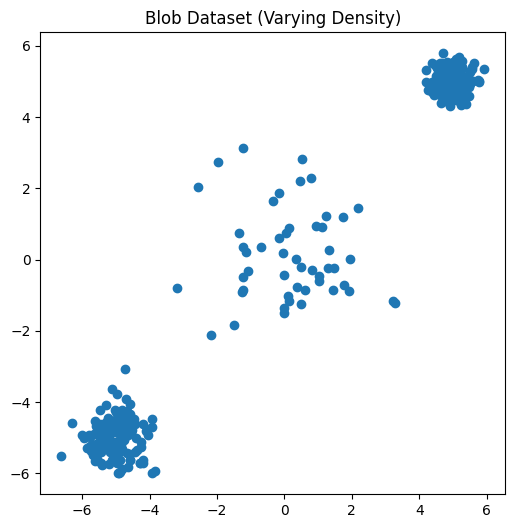

In [52]:
#Done for you
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X_blobs, _ = make_blobs(
    n_samples=[150, 50, 200],
    centers=[(-5, -5), (0, 0), (5, 5)],
    cluster_std=[0.5, 1.5, 0.3],
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X_blobs[:,0], X_blobs[:,1])
plt.title("Blob Dataset (Varying Density)")
plt.show()


### TODO 1: Scaling

Scale the dataset using StandardScaler.

Think:
- Why is scaling important here?
- What happens if we skip scaling?


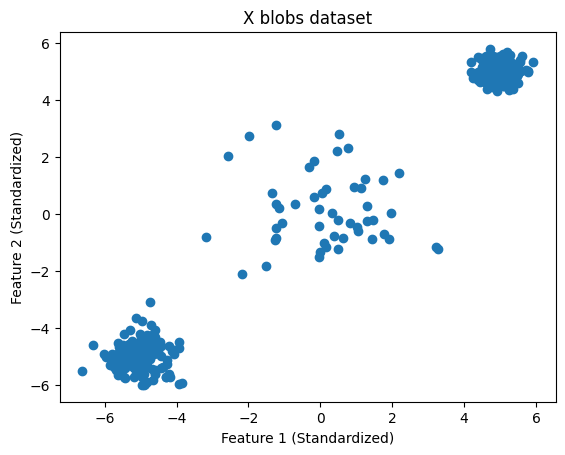

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np


# Ensure data is generated if kernel was restarted
# TODO: Scale the dataset and verify that the mean is ~0 and variance is ~1
# Challenge: Check the summary statistics of the scaled data

scaler = StandardScaler()

scaler_X_blobs = scaler.fit_transform(X_blobs)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1])
plt.title("X blobs dataset")
plt.xlabel("Feature 1 (Standardized)")
plt.ylabel("Feature 2 (Standardized)")
plt.show()

In [54]:
print(scaler_X_blobs.mean())
print(scaler_X_blobs.var())


1.5543122344752193e-17
1.0


In [55]:
scaled_df = pd.DataFrame(scaler_X_blobs)

scaled_df.describe()

,0,1
count,4.000000e+02,4.000000e+02
mean,5.773160e-17,-6.439294e-17
std,1.001252e+00,1.001252e+00
min,-1.552926e+00,-1.423594e+00
25%,-1.172044e+00,-1.159617e+00
50%,6.645817e-01,6.608559e-01
75%,9.330801e-01,9.311268e-01
max,1.132521e+00,1.103948e+00



### TODO 2: DBSCAN on Blob Dataset

Apply DBSCAN.
Experiment with different values of eps and min_samples.


In [56]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# TODO: Implement DBSCAN
# Challenge: Create a function that loops through a grid of eps [0.2, 0.4, 0.6]
# and min_samples [2, 5, 10] and plots the results in a 3x3 subplot grid.


dbscan = DBSCAN(eps=0.5, min_samples=3)
dbscan.fit(scaler_X_blobs)

label_dbscan = dbscan.labels_

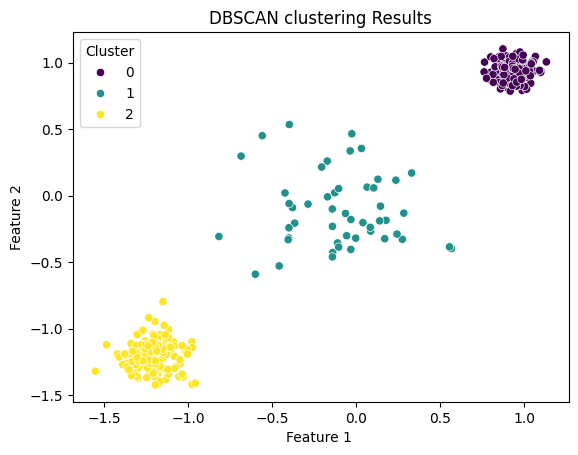

In [57]:
sns.scatterplot(x = scaler_X_blobs[:, 0], y=scaler_X_blobs[:,1], hue=label_dbscan, palette='viridis')

plt.title("DBSCAN clustering Results")
plt.xlabel("Feature 1 ")
plt.ylabel("Feature 2")
plt.legend(title='Cluster')
plt.show()


### TODO 3: k-Distance Plot

Use a k-distance plot to estimate eps.


In [58]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# TODO: Create k-distance plot
# Challenge: Use the 'knee' point detection logic.
# Calculate distances to the 5th nearest neighbor, sort them, and plot.

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(scaler_X_blobs)

In [59]:
distances, indicas = neighbors_fit.kneighbors(scaler_X_blobs)

In [60]:
distance = distances[:, 4]

In [61]:
distance = np.sort(distance)

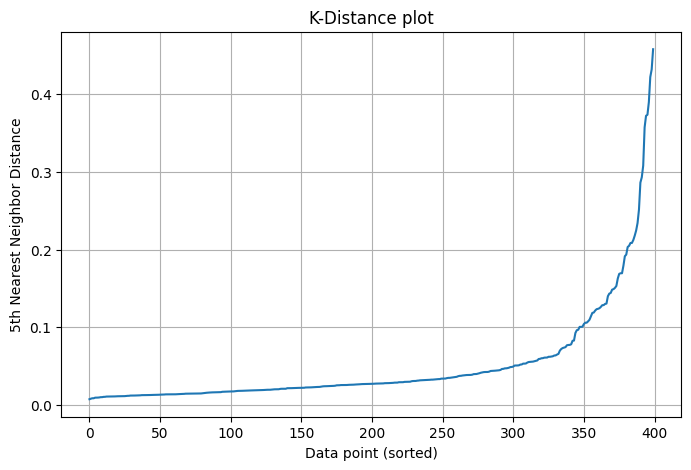

In [62]:
plt.figure(figsize=(8, 5))
plt.plot(distance)

plt.title("K-Distance plot")
plt.xlabel("Data point (sorted)")
plt.ylabel("5th Nearest Neighbor Distance")
plt.grid(True)
plt.show()


## Dataset 2: Circular Dataset

This dataset contains non-linear circular clusters.


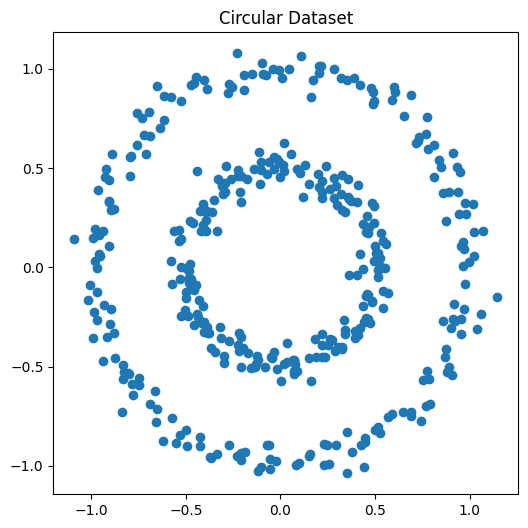

In [63]:
#Done for you
from sklearn.datasets import make_circles

X_circles, _ = make_circles(
    n_samples=400,
    factor=0.5,
    noise=0.05,
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X_circles[:,0], X_circles[:,1])
plt.title("Circular Dataset")
plt.show()


### TODO 4: DBSCAN on Circular Data

Apply DBSCAN and observe cluster shape.


In [64]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Ensure data is generated
# TODO: Compare DBSCAN results side-by-side with K-Means (k=2)
# KMeans (Expect failure for non-convex shapes)
# DBSCAN (Expect success for dense regions)

scaler = StandardScaler()
scaler_X_circles = scaler.fit_transform(X_circles)

In [65]:
kmeans = KMeans(n_clusters=2, init="k-means++",
                max_iter=300, random_state=42)
kmeans_labels = kmeans.fit_predict(scaler_X_circles)

In [66]:
dbscan = DBSCAN(eps=0.5, min_samples=3)
dbscan_labels = dbscan.fit_predict(scaler_X_circles)

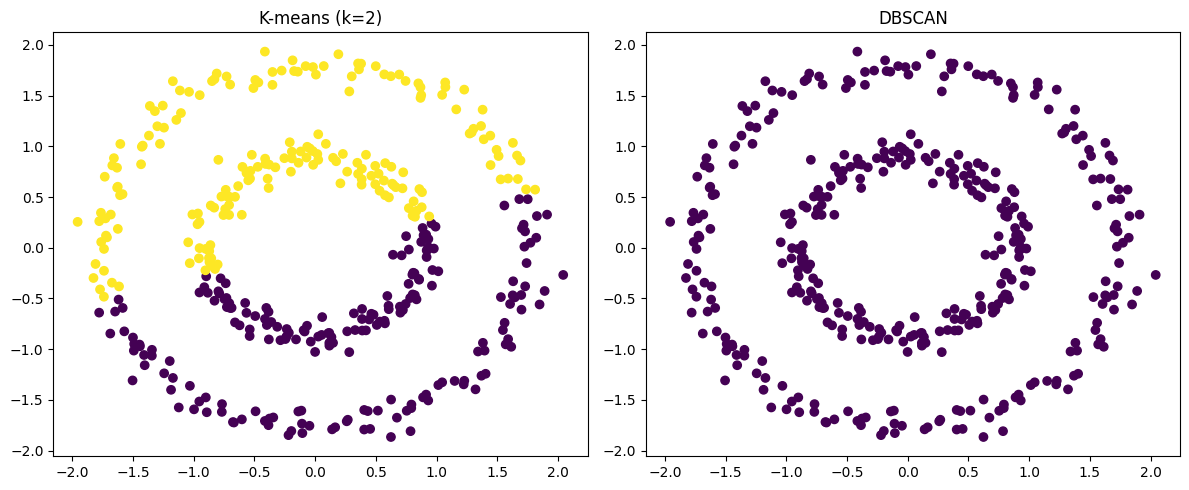

In [67]:
# plot side by side
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.scatter(scaler_X_circles[:, 0], scaler_X_circles[:, 1], c=kmeans_labels, cmap='viridis')
plt.title("K-means (k=2)")


plt.subplot(1, 2, 2)
plt.scatter(scaler_X_circles[:, 0], scaler_X_circles[:, 1], c=dbscan_labels, cmap='viridis')
plt.title("DBSCAN")

plt.tight_layout()
plt.show()


## Hierarchical Clustering Practice



### TODO 5: Agglomerative Clustering

Try different linkage methods:
single, complete, average, ward


In [71]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

# TODO: Apply hierarchical clustering
# Challenge: For each linkage method, calculate the Silhouette Score.

linkages = ['single', 'complete', 'average', 'ward']

for linkage in linkages:

  model = AgglomerativeClustering(
      n_clusters= 3,
      linkage = linkage
  )

  labels = model.fit_predict(scaler_X_circles)
  score = silhouette_score(scaler_X_circles, labels)
  print(f"{linkage} : {score:.3f}")

single : 0.011
complete : 0.335
average : 0.346
ward : 0.344


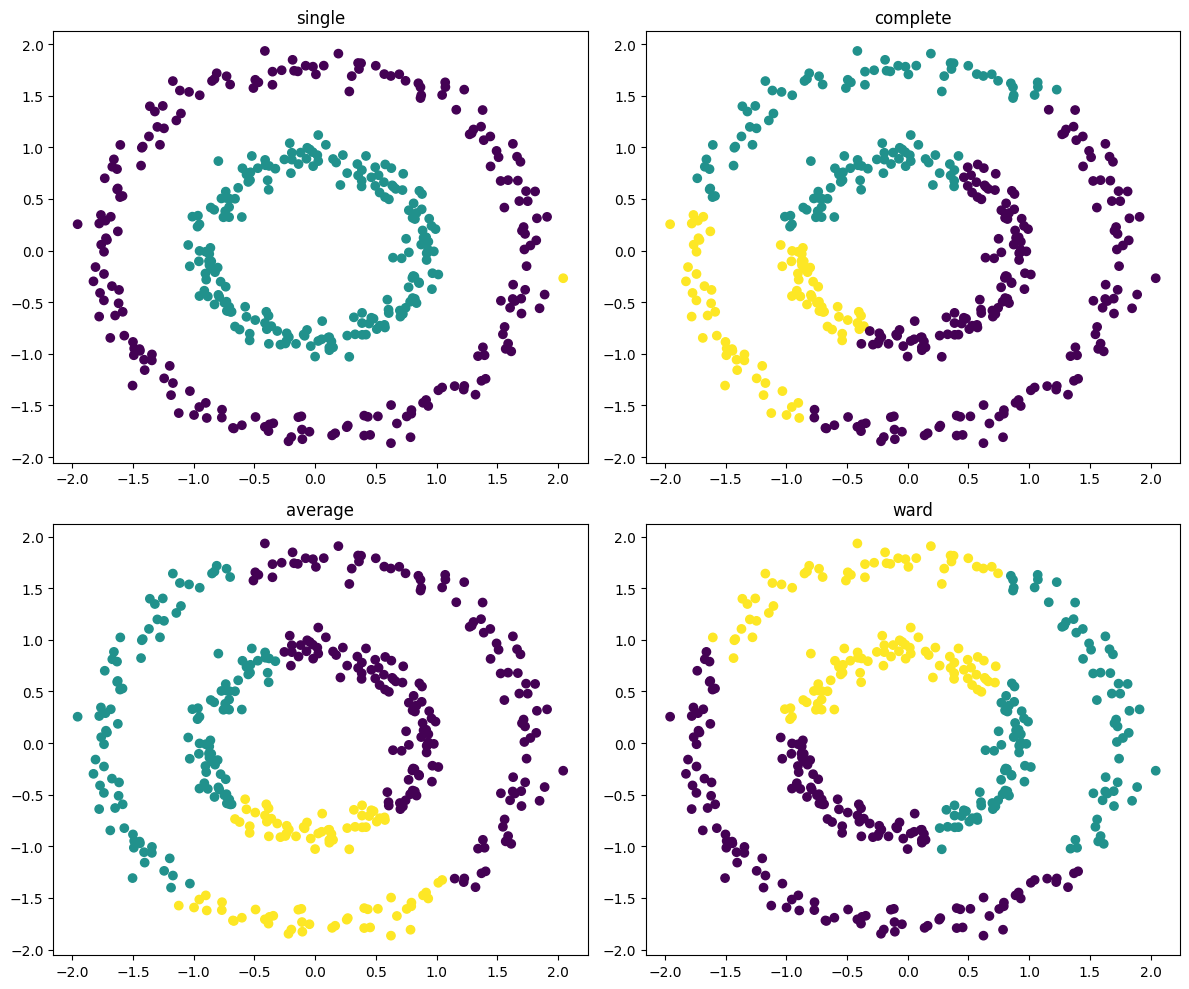

In [72]:
# 4 linkages graph

linkages = ['single', 'complete', 'average', 'ward']
plt.figure(figsize=(12,10))

for i, linkage in enumerate(linkages):

    model = AgglomerativeClustering(
        n_clusters=3,
        linkage=linkage
    )

    labels = model.fit_predict(scaler_X_circles)

    plt.subplot(2,2,i+1)

    plt.scatter(
        scaler_X_circles[:,0],
        scaler_X_circles[:,1],
        c=labels,
        cmap="viridis"
    )

    plt.title(linkage)

plt.tight_layout()
plt.show()


### TODO 6: Dendrogram

Create a dendrogram using Ward linkage.


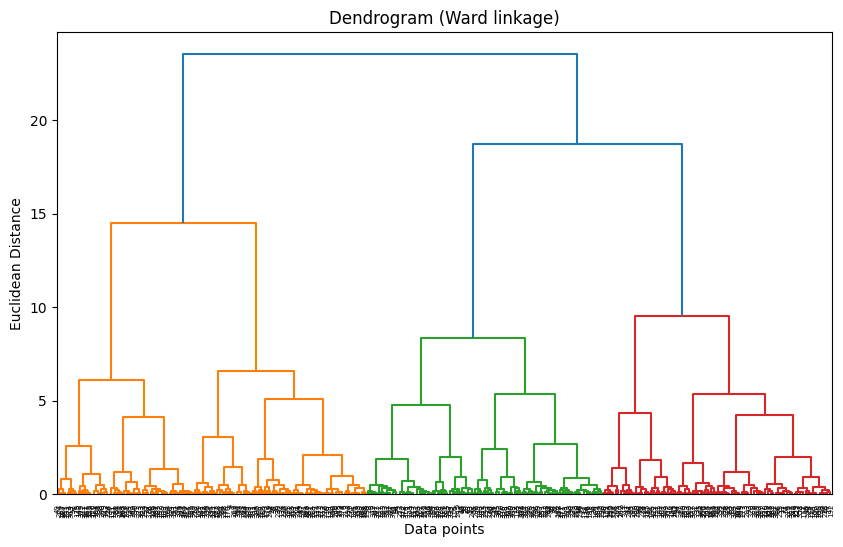

In [73]:
from scipy.cluster.hierarchy import dendrogram, linkage

# TODO: Create dendrogram here

# Ward linkage matrix
Z = linkage(scaler_X_circles, method="ward")

plt.figure(figsize=(10, 6))
dendrogram(Z)

plt.title("Dendrogram (Ward linkage)")
plt.xlabel("Data points")
plt.ylabel("Euclidean Distance")
plt.show()

## The Grand Challenge: 3D Density Optimization

In this final, hard challenge, we will step into 3D space and automate our parameter selection.

### Requirements:
1. **Generate 3D Data**: Use `make_blobs` to create 1000 samples in 3D space with varying standard deviations.
2. **Parameter Grid Search**: Write a loop that tests `eps` from 0.1 to 1.0 and `min_samples` from 2 to 10.
3. **Optimization**: Find the combination that maximizes the `silhouette_score` (excluding noise points).
4. **3D Visualization**: Plot the final optimized clusters using a 3D scatter plot.

In [74]:
# Step 1: Generate 3D Data

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

X, y = make_blobs(
    n_samples=1000,
    centers=4,
    n_features=3,   #3D
    cluster_std = [1.0, 1.5, 2.0, 0.8],
    random_state = 42
)

scaler = StandardScaler()
X_scaler = scaler.fit_transform(X)

In [78]:
# Step 2: Grid Search for DBSCAN Parameters

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

best_score = -1
best_eps = None
best_min_samples = None
best_labels = None

for eps in np.arange(0.1, 1.1, 0.1):

  for min_samples in range(2, 11):
    dbscan = DBSCAN(
        eps = eps,
        min_samples = min_samples
    )

    labels = dbscan.fit_predict(X_scaler)

    # noise remove
    mask = labels != -1

    # atlest 2 cluster
    if len(set(labels[mask])) > 1:

      score = silhouette_score(
          X_scaler[mask],
          labels[mask]
      )

      if score>best_score:
        best_score = score
        best_eps = eps
        best_min_samples = min_samples
        best_labels = labels

In [79]:
# Step 3: Best Parameter Print

print("Best eps:", best_eps)
print("Best min_samples:", best_min_samples)
print("Best Silhouette Score:", best_score)

Best eps: 0.1
Best min_samples: 10
Best Silhouette Score: 0.9120062191358754


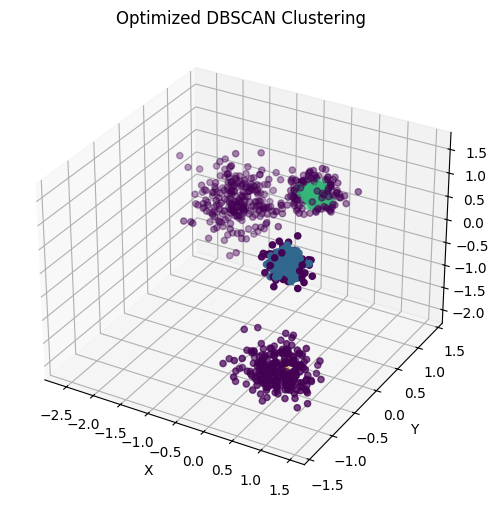

In [80]:
# Step 4: 3D Visualization

fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection = "3d")

ax.scatter(
    X_scaler[:, 0],
    X_scaler[:, 1],
    X_scaler[:, 2],
    c=best_labels,
    cmap="viridis"
)

ax.set_title("Optimized DBSCAN Clustering")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()